<a href="https://colab.research.google.com/github/shivansh2310/The-elements-of-quantitative-investing-/blob/main/Covariance_Math_%26_The_Structural_Shift_(Chapters_5%E2%80%938).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### A. The Failure of Empirical Covariance

* When you have a few assets and lots of data, sample covariance works fine.

* As your universe grows (e.g., trying to optimize 500 stocks with 2 years of daily data), the sample covariance matrix becomes mathematically unstable (ill-conditioned or singular). The optimizer will mercilessly exploit the estimation errors, taking extreme long/short positions in assets that just look correlated due to noise.

### B. Shrinkage and Structural Models

* Shrinkage Estimators (Ledoit-Wolf): This is the industry standard. You take the noisy sample covariance matrix and "shrink" it toward a highly structured, less noisy target matrix (like a constant correlation matrix). It is a bias-variance tradeoff: you introduce a little bias to massively reduce the variance of the estimator.

* The Precision Matrix: Portfolio optimization actually relies on the inverse of the covariance matrix (the precision matrix). If the covariance matrix is ill-conditioned, inverting it blows up the estimation errors.

### C. Fundamental vs. Statistical Factor Models

* Fundamental: You define the factors (e.g., Value, Momentum, Tech, Energy). You use cross-sectional regressions to find the factor returns at each time step.

* Statistical (PCA): You let the math find the factors. Principal Component Analysis extracts orthogonal vectors that explain the most variance.

* PCA factors are orthogonal by definition, making the math clean, but they often lack economic intuition. Fundamental models are messier but interpretable.

## Building the Multi-Factor Risk Matrix

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import LedoitWolf

In [11]:
def etf_data(etf_list):
  data = yf.download(etf_list, period="5y")
  adj_close_price = data['Close']
  return adj_close_price

etf_list = [
    "SPY",  # Market Proxy
    "XLK",  # Technology
    "XLE",  # Energy
    "XLF",  # Financials
    "XLV",  # Health Care
    "XLI",  # Industrials
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLU",  # Utilities
    "XLB",  # Materials
    "XLRE", # Real Estate
    "XLC",  # Communication Services
    "IGF",  # Global Infrastructure
    "DBA"   # Agriculture
]

etf_data = etf_data(etf_list)
etf_data.head()



/tmp/ipykernel_12536/4013707157.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(etf_list, period="5y")
[*********************100%***********************]  14 of 14 completed


Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,
2021-06-04,16.775139,40.890472,394.701263,39.785744,75.280098,23.168657,35.259861,97.609016,67.387688,62.700695,37.783657,28.089272,112.644730,82.107002
2021-06-07,16.766315,41.123188,394.318268,39.301491,75.669853,23.068914,35.030724,96.932579,67.373245,62.595497,38.139774,28.140820,113.050690,82.107002
2021-06-08,16.836908,41.011143,394.402374,39.373913,75.451225,23.268398,34.939056,97.182777,67.378052,62.069489,38.343281,27.900259,112.700111,82.769516
2021-06-09,16.792788,41.269722,393.813873,39.066151,75.375160,23.122942,34.609112,96.191292,67.426163,61.771400,38.385685,28.149408,113.788795,82.313438
2021-06-10,16.889854,41.276711,395.644501,38.830811,75.783943,23.093849,34.205818,95.718750,67.921883,62.157146,38.775719,28.334122,115.735580,82.702286


In [12]:
simple_return = etf_data.pct_change().dropna()
simple_return.head()

Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,
2021-06-07,-0.000526,0.005691,-0.000970,-0.012172,0.005177,-0.004305,-0.006499,-0.006930,-0.000214,-0.001678,0.009425,0.001835,0.003604,0.000000
2021-06-08,0.004210,-0.002725,0.000213,0.001843,-0.002889,0.008647,-0.002617,0.002581,0.000071,-0.008403,0.005336,-0.008548,-0.003101,0.008069
2021-06-09,-0.002620,0.006305,-0.001492,-0.007816,-0.001008,-0.006251,-0.009443,-0.010202,0.000714,-0.004802,0.001106,0.008930,0.009660,-0.005510
2021-06-10,0.005780,0.000169,0.004648,-0.006024,0.005423,-0.001258,-0.011653,-0.004913,0.007352,0.006245,0.010161,0.006562,0.017109,0.004724
2021-06-11,-0.005225,0.002330,0.001653,0.003730,0.001129,-0.003419,0.006431,0.002033,0.005952,0.000564,-0.006341,0.002274,-0.007095,0.005457


In [13]:
simple_return.describe()

Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,0.000409,0.000428,0.000577,0.000276,0.000407,0.000878,0.000379,0.000529,0.000968,0.000248,0.000192,0.000413,0.000278,0.000395
std,0.008869,0.008812,0.010741,0.011930,0.013022,0.016388,0.011751,0.010978,0.015679,0.008375,0.012010,0.010911,0.009282,0.014983
min,-0.048642,-0.056453,-0.058543,-0.062590,-0.066903,-0.091999,-0.073181,-0.062853,-0.068248,-0.064348,-0.048203,-0.055626,-0.054845,-0.065384
25%,-0.004993,-0.004432,-0.004519,-0.007054,-0.006094,-0.008185,-0.005734,-0.005649,-0.007700,-0.004526,-0.006423,-0.006079,-0.005144,-0.007736
50%,0.000463,0.000638,0.000732,0.000370,0.000810,0.001662,0.000603,0.000796,0.001682,0.000526,0.000546,0.000894,0.000299,0.001058
75%,0.005881,0.005953,0.006255,0.007383,0.007404,0.010257,0.007164,0.007085,0.009994,0.005124,0.007222,0.007135,0.005797,0.008887
max,0.030278,0.045620,0.105019,0.087384,0.088355,0.077447,0.075364,0.088816,0.134257,0.038769,0.076666,0.047148,0.043465,0.108881


<Axes: xlabel='Date'>

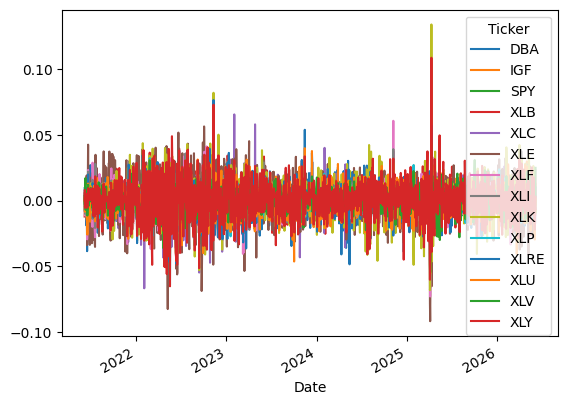

In [14]:
simple_return.plot()

Standard empirical coviarnce matrix

In [15]:
cov_matrix = simple_return.cov()
cov_matrix

Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,
DBA,0.000079,0.000014,0.000015,0.000022,0.000015,0.000040,0.000017,0.000016,0.000018,0.000006,0.000011,0.000006,0.000005,0.000015
IGF,0.000014,0.000078,0.000063,0.000074,0.000060,0.000071,0.000067,0.000066,0.000069,0.000043,0.000075,0.000073,0.000045,0.000073
SPY,0.000015,0.000063,0.000115,0.000101,0.000117,0.000074,0.000101,0.000101,0.000156,0.000046,0.000084,0.000053,0.000065,0.000141
XLB,0.000022,0.000074,0.000101,0.000142,0.000096,0.000098,0.000106,0.000110,0.000117,0.000055,0.000095,0.000064,0.000067,0.000121
XLC,0.000015,0.000060,0.000117,0.000096,0.000170,0.000060,0.000100,0.000094,0.000154,0.000043,0.000083,0.000045,0.000061,0.000151
XLE,0.000040,0.000071,0.000074,0.000098,0.000060,0.000269,0.000094,0.000086,0.000069,0.000033,0.000057,0.000047,0.000039,0.000072
XLF,0.000017,0.000067,0.000101,0.000106,0.000100,0.000094,0.000138,0.000105,0.000112,0.000049,0.000085,0.000054,0.000064,0.000121
XLI,0.000016,0.000066,0.000101,0.000110,0.000094,0.000086,0.000105,0.000121,0.000122,0.000048,0.000087,0.000060,0.000062,0.000121
XLK,0.000018,0.000069,0.000156,0.000117,0.000154,0.000069,0.000112,0.000122,0.000246,0.000040,0.000092,0.000049,0.000068,0.000185


In [16]:
cond_num_matrix = np.linalg.cond(cov_matrix)
cond_num_matrix

np.float64(1231.2886984566376)

### Applying Shrinkage

In [19]:
X = simple_return
lw = LedoitWolf()
lw.fit(X)

shrinkage_matrix = lw.covariance_
precesion_matrix = lw.precision_
shrinkage_coef = lw.shrinkage_

# print(f"Shrinkage Matrix:\n{shrinkage_matrix}")
# print(f"Precision Matrix:\n{precesion_matrix}")
print(f"Shrinkage Coefficient: \n{shrinkage_coef}")

Shrinkage Coefficient: 
0.010854558345376495


In [20]:
cond_num_matrix_lw = np.linalg.cond(shrinkage_matrix)
cond_num_matrix_lw

np.float64(465.63933142108885)